In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from keras.optimizers import Adam
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers.schedules import ExponentialDecay
import cv2
from keras.models import model_from_json
import numpy as np
import os
import matplotlib as plt

In [2]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator



(28709, 224, 224, 3) (0,)


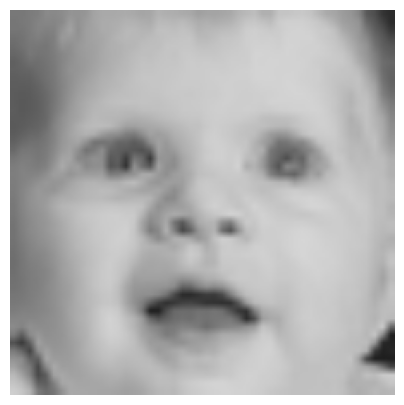

In [4]:
train_path= r"C:\Users\vasuv\Downloads\Emotion dect\train"
x_train=[]
train_labels = []
classes = 7
for folder in os.listdir(train_path):

    sub_path=train_path+"/"+folder

    for img in os.listdir(sub_path):

        image_path=sub_path+"/"+img

        img_arr=cv2.imread(image_path)

        img_arr=cv2.resize(img_arr,(224,224))
        x_train.append(img_arr)
plt.figure(figsize=(5,5))
plt.axis('off')
plt.imshow(img_arr)

train_x=np.array(x_train)
train_labels = np.array(train_labels)
print(train_x.shape, train_labels.shape)


In [5]:
train_data_gen = ImageDataGenerator(rescale=1./255,
                                      rotation_range=40,
                                      width_shift_range=0.2,
                                      height_shift_range=0.2,
                                      shear_range=0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      fill_mode='nearest')
train_generator = train_data_gen.flow_from_directory(
    train_path,
    target_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    class_mode='categorical')



Found 28709 images belonging to 7 classes.


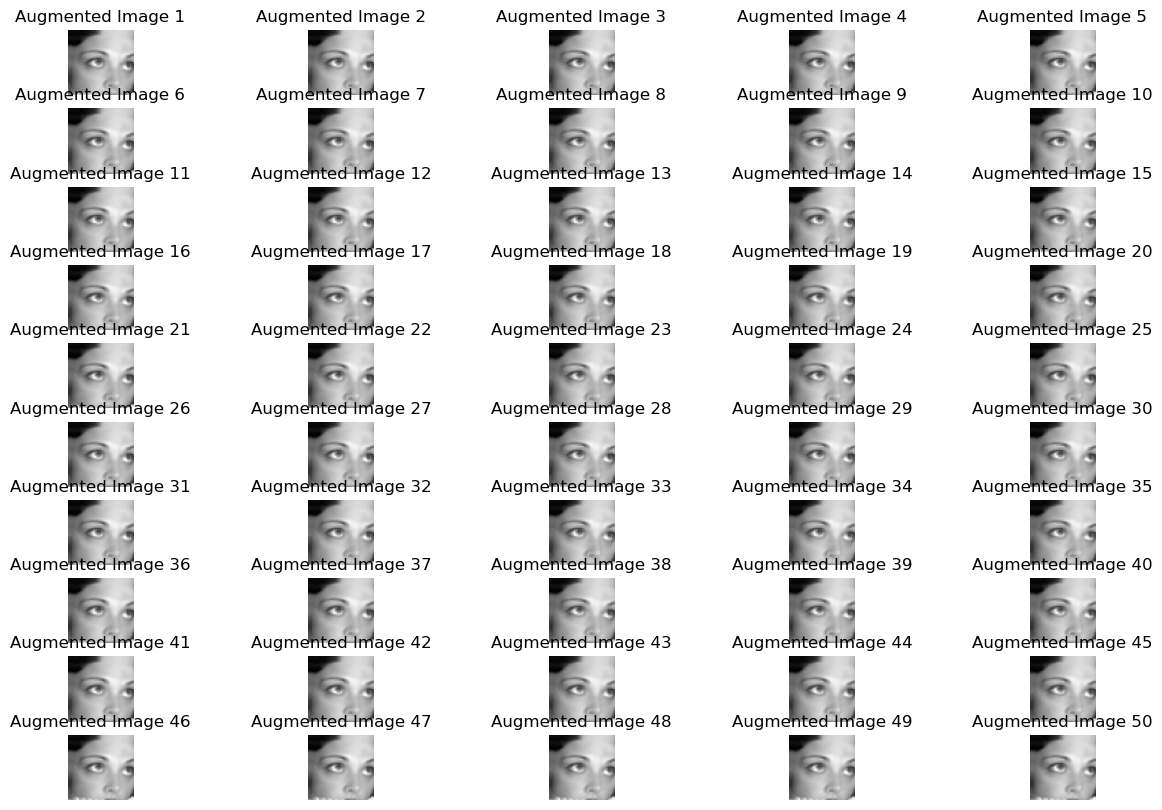

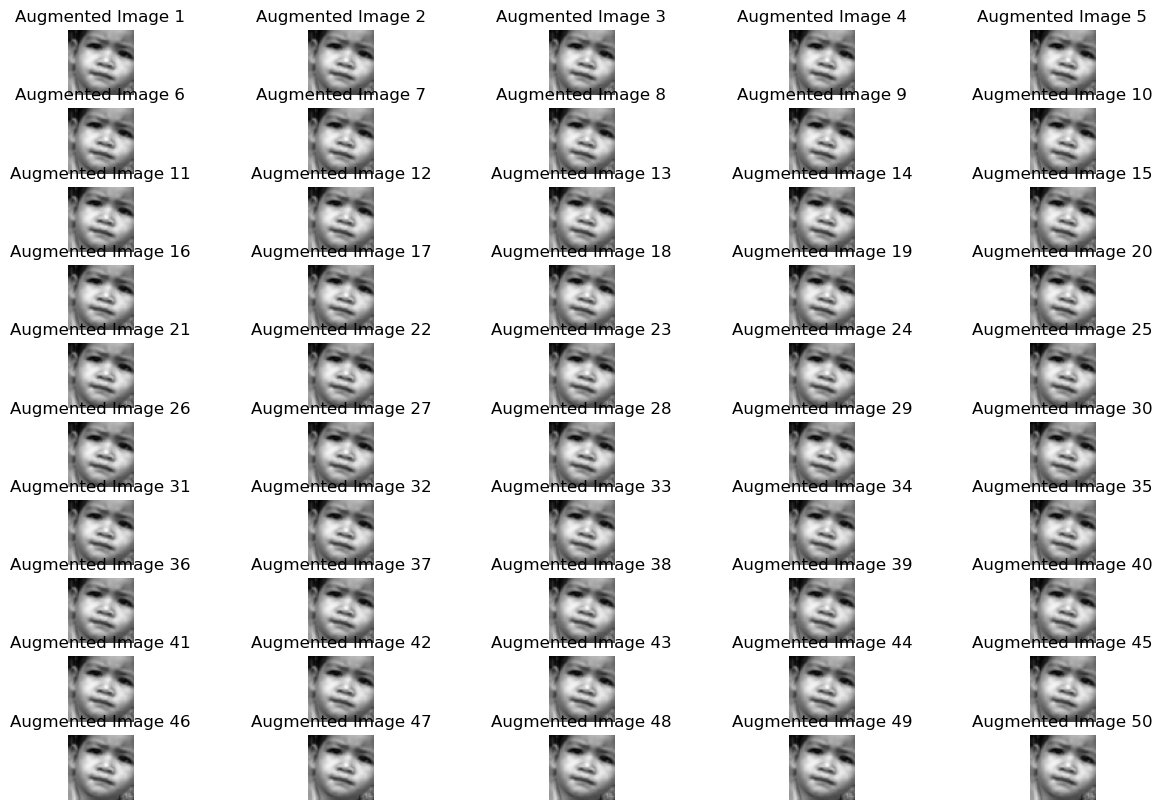

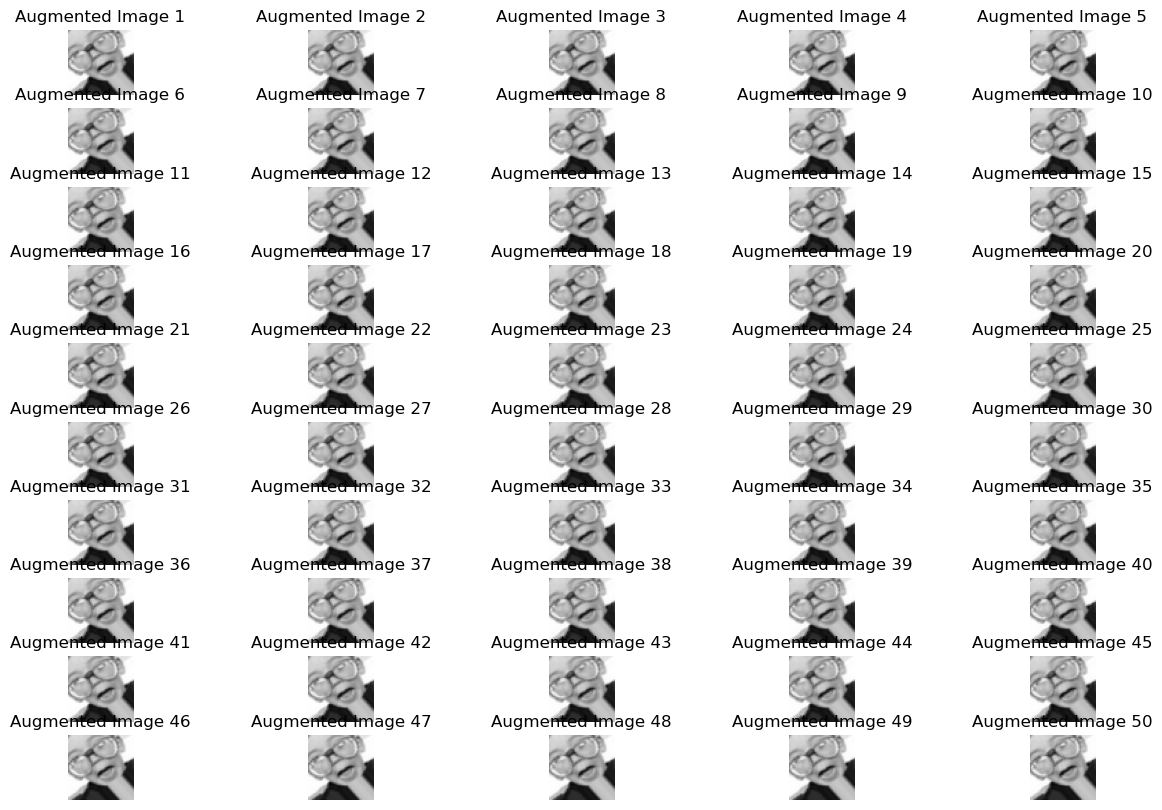

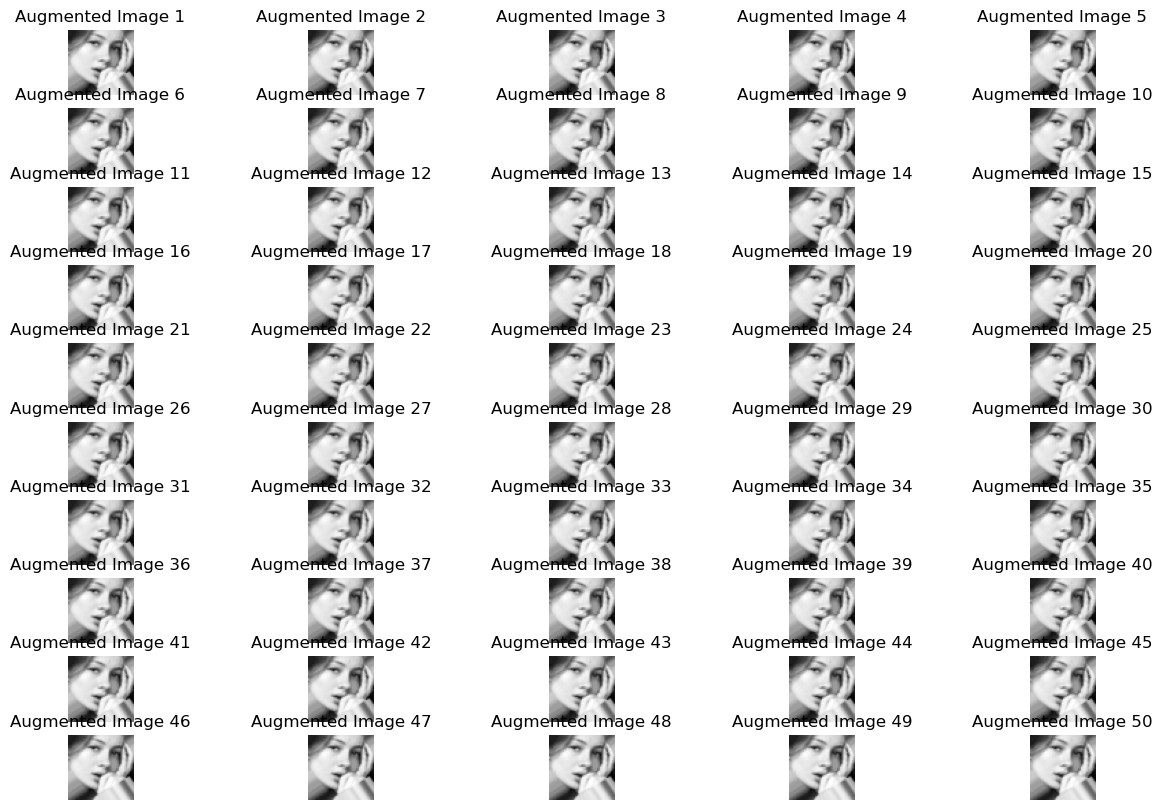

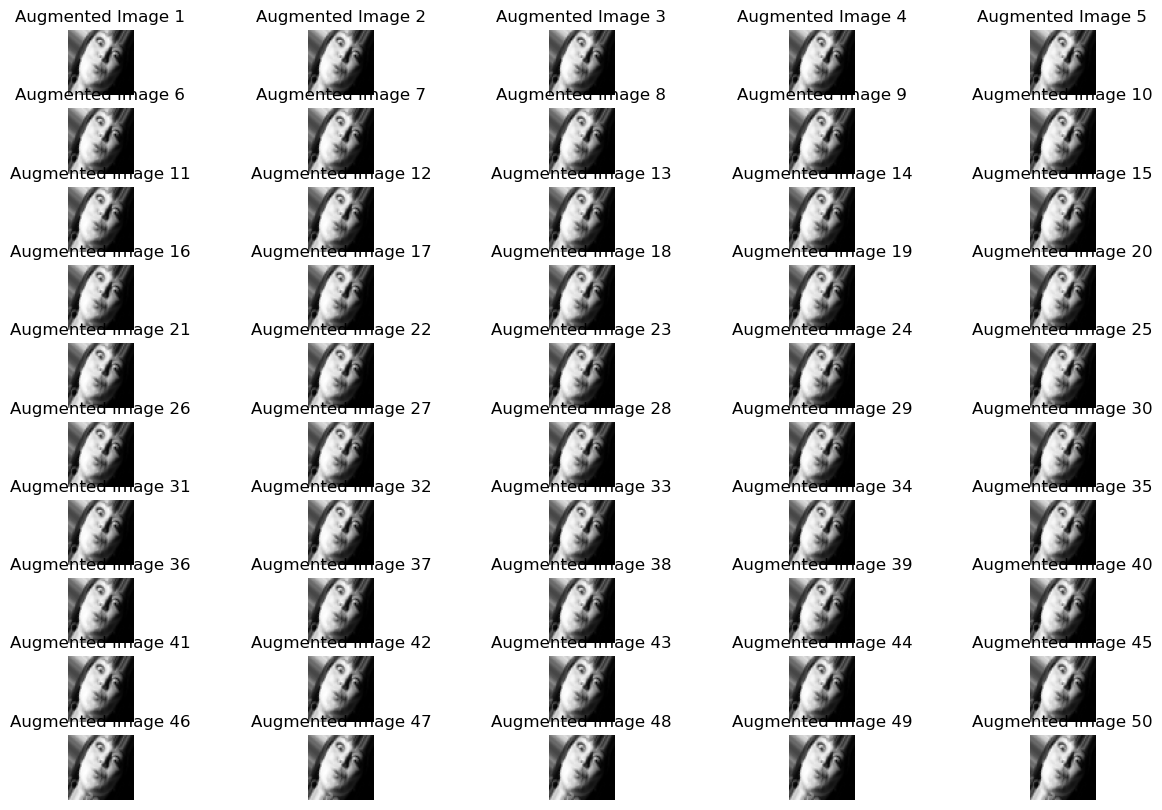

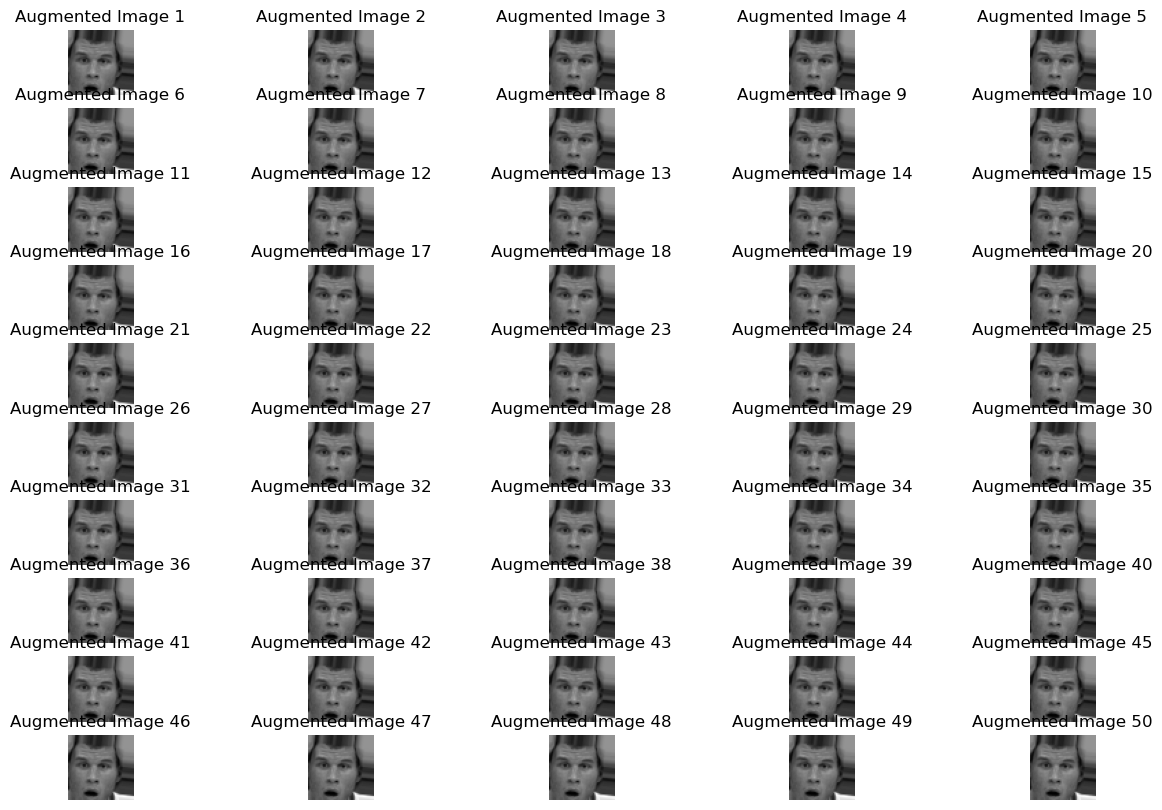

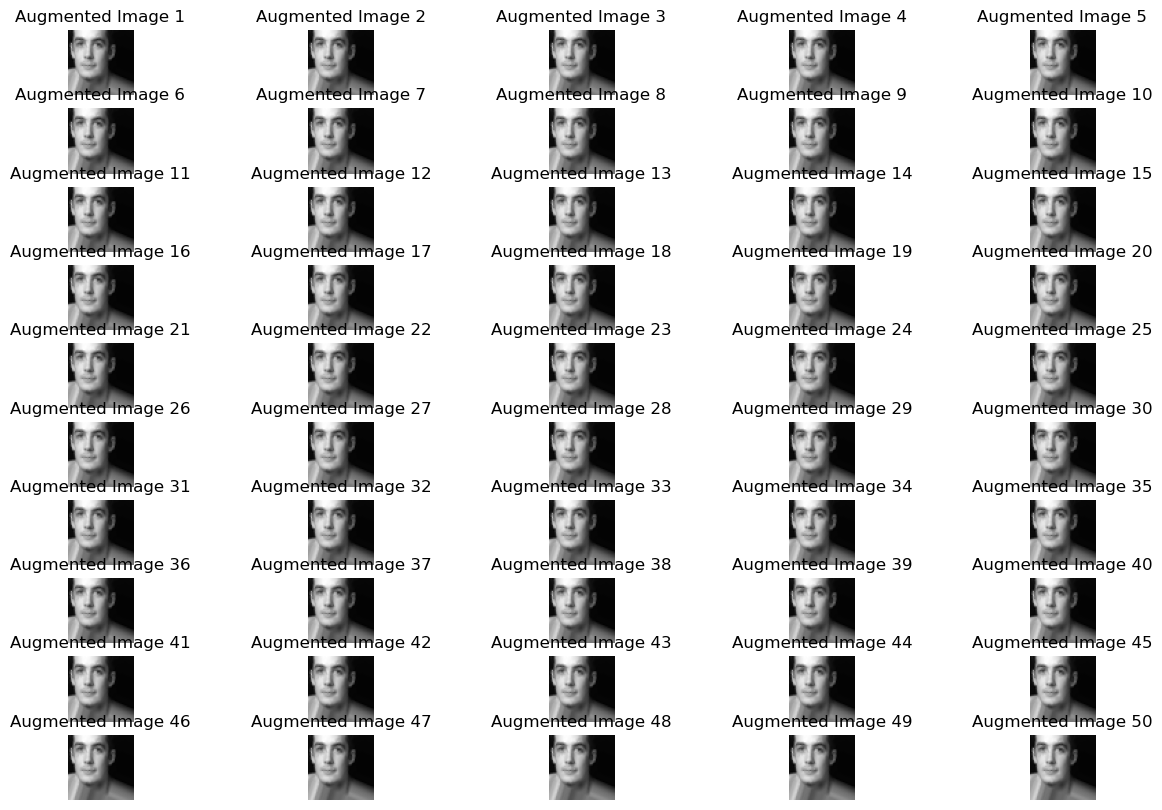

In [6]:
import matplotlib.pyplot as plt

num_augmented_images = 7  # Set the number of augmented images to generate for visualization

for i in range(num_augmented_images):
    augmented_batch = next(train_generator)  # Use next() instead of train_generator.next()
    augmented_image = augmented_batch[0][0]  # Get the first image from the batch

    # Plot the augmented image
    plt.figure(figsize=(15, 10))
    for j in range(50):  # Fix loop variable name from 'i' to 'j'
        plt.subplot(10, 5, j + 1)
        plt.imshow(augmented_image.squeeze(), cmap='gray')  # Ensure correct shape for grayscale images
        plt.axis('off')
        plt.title(f'Augmented Image {j+1}')
    
    plt.show()  # Move plt.show() outside the inner loop to display all subplots together


(7178, 224, 224, 3) (0,)


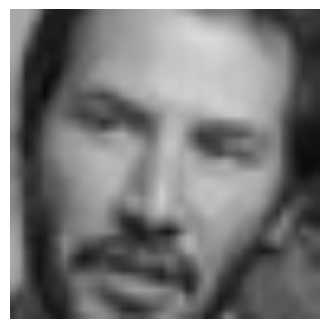

In [7]:
test_path=r"C:\Users\vasuv\Downloads\Emotion dect\test"
x_test=[]
test_labels = []
classes = 7
for folder in os.listdir(test_path):

    sub_path=test_path+"/"+folder

    for img in os.listdir(sub_path):

        image_path=sub_path+"/"+img

        img_arr=cv2.imread(image_path)

        img_arr=cv2.resize(img_arr,(224,224))
        x_test.append(img_arr)
plt.figure(figsize=(4,5))
plt.axis('off')
plt.imshow(img_arr)

test_x=np.array(x_test)
test_labels = np.array(test_labels)
print(test_x.shape, test_labels.shape) 

In [8]:

validation_data_gen = ImageDataGenerator(rescale=1./255,
                                      rotation_range=40,
                                      width_shift_range=0.2,
                                      height_shift_range=0.2,
                                      shear_range=0.2,
                                      zoom_range=0.2,
                                      horizontal_flip=True,
                                      fill_mode='nearest')
validation_generator = validation_data_gen.flow_from_directory(
        test_path,
        target_size=(48, 48),
        batch_size=64,
        color_mode="grayscale",
        class_mode='categorical')

Found 7178 images belonging to 7 classes.


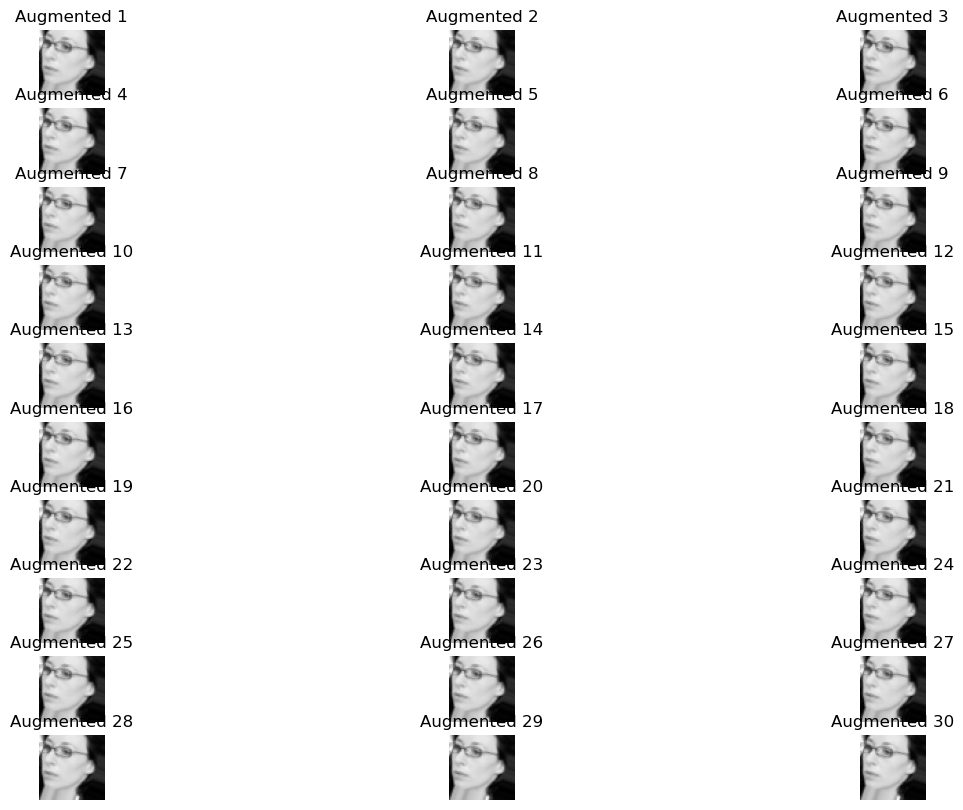

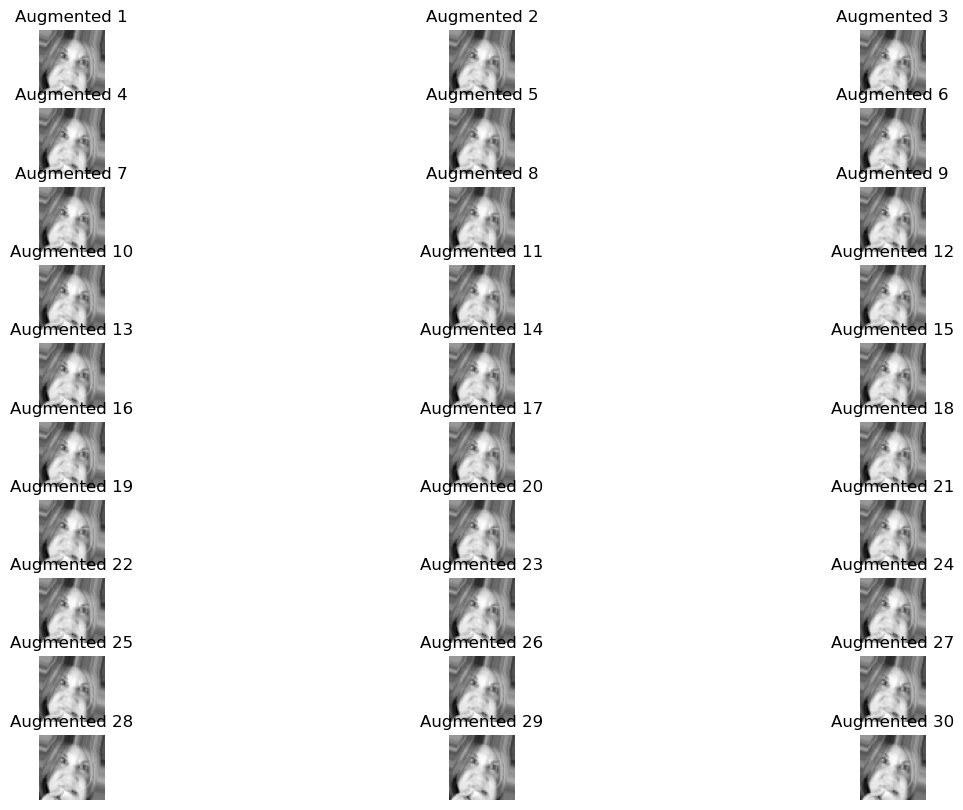

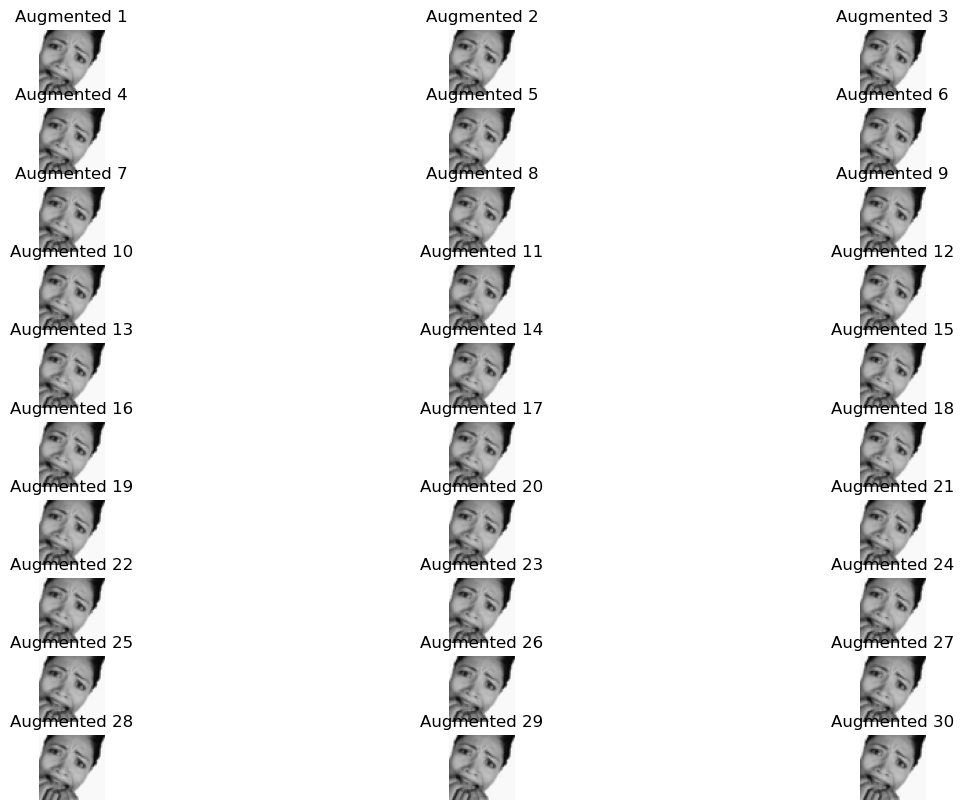

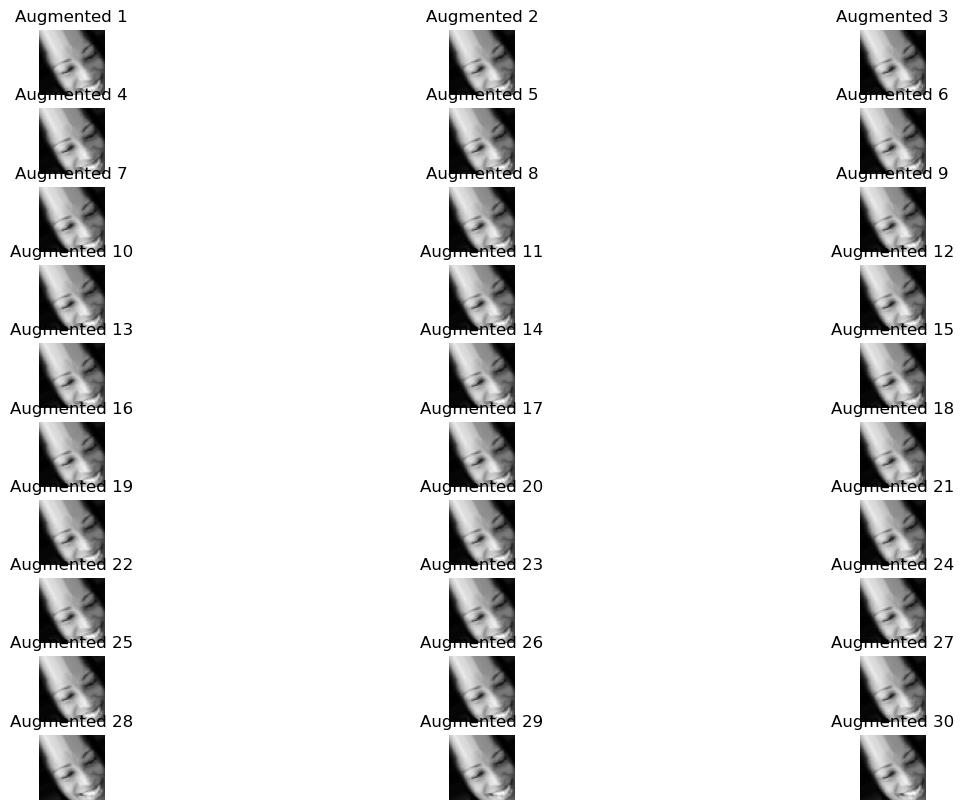

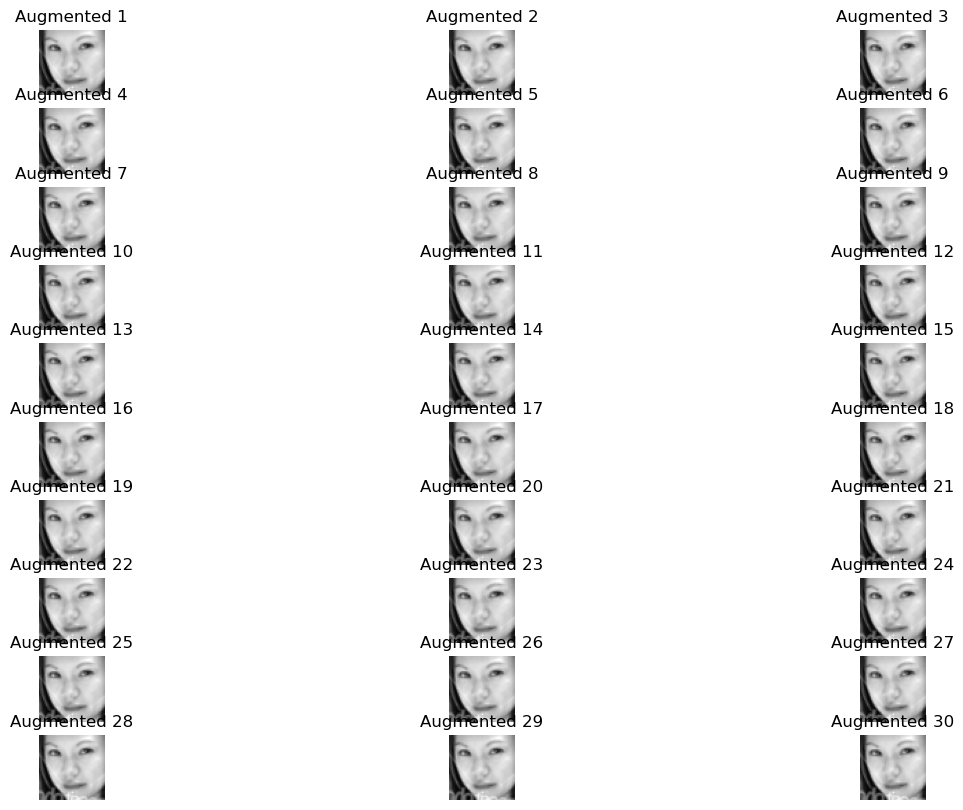

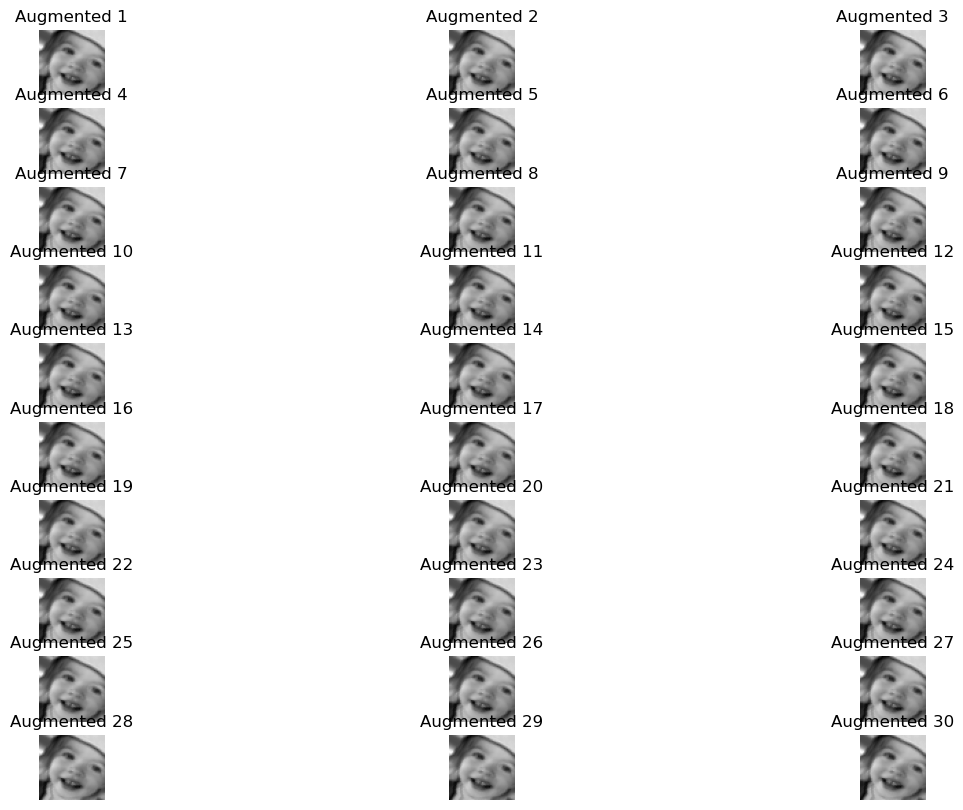

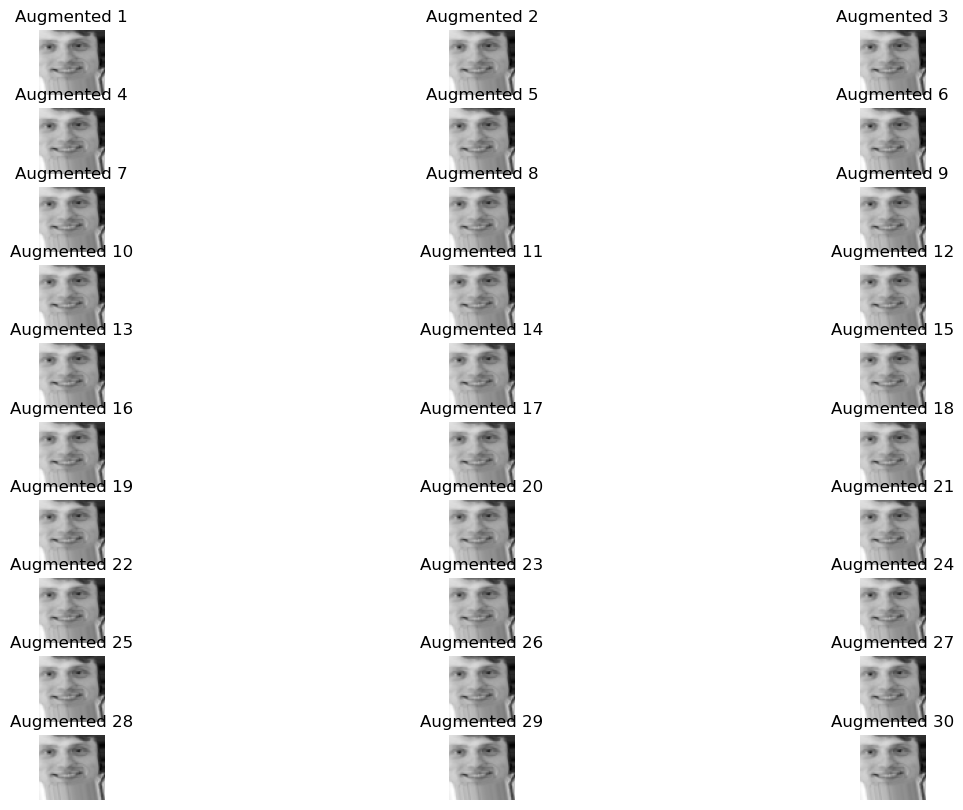

In [9]:
import matplotlib.pyplot as plt

num_augmented_images = 7  # Number of augmented images to generate for visualization

for i in range(num_augmented_images):
    augmented_batch = next(train_generator)  # Use next() instead of train_generator.next()
    augmented_image = augmented_batch[0][0]  # Get the first image from the batch

    # Plot the augmented images in a grid
    plt.figure(figsize=(15, 10))
    for j in range(30):  # Fix loop variable name from 'i' to 'j'
        plt.subplot(10, 3, j + 1)  # 10 rows, 3 columns grid
        plt.imshow(augmented_image.squeeze(), cmap='gray')  # Ensure correct shape for grayscale images
        plt.axis('off')
        plt.title(f'Augmented {j+1}')
    
    plt.show()  # Show all images in a single figure


In [10]:
emotion_model = Sequential()
 
emotion_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', 
                         input_shape=(48, 48, 1)))
emotion_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))
 
emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
emotion_model.add(MaxPooling2D(pool_size=(2, 2)))
emotion_model.add(Dropout(0.25))
 
emotion_model.add(Flatten())
emotion_model.add(Dense(1024, activation='relu'))
emotion_model.add(Dropout(0.5))
emotion_model.add(Dense(7, activation='softmax'))
 
emotion_model.summary()
 
cv2.ocl.setUseOpenCL(False)
 
initial_learning_rate = 0.0001
lr_schedule = ExponentialDecay(initial_learning_rate, decay_steps=100000, 
                               decay_rate=0.96)
 
optimizer = Adam(learning_rate=lr_schedule)
 
emotion_model.compile(loss='categorical_crossentropy', optimizer=optimizer, 
                      metrics=['accuracy'])


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 46, 46, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 44, 44, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 20, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 10, 10, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │           7,175 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,345,607 (8.95 MB)

 Trainable params: 2,345,607 (8.95 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
emotion_model_info = emotion_model.fit(
    train_generator,
    steps_per_epoch=28709 // 64,
    epochs=2,
    validation_data=validation_generator,
    validation_steps=7178 // 64
)


Epoch 1/2
448/448 ━━━━━━━━━━━━━━━━━━━━ 162s 343ms/step - accuracy: 0.2417 - loss: 1.8378 - val_accuracy: 0.2492 - val_loss: 1.8036
Epoch 2/2
448/448 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.1719 - loss: 1.8404 - val_accuracy: 0.2522 - val_loss: 1.8027


In [12]:
emotion_model.evaluate(validation_generator)


113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - accuracy: 0.2619 - loss: 1.7992


[1.8040395975112915, 0.2532739043235779]

In [13]:
accuracy = emotion_model_info.history['accuracy']
val_accuracy = emotion_model_info.history['val_accuracy']
loss = emotion_model_info.history['loss']
val_loss = emotion_model_info.history['val_loss']


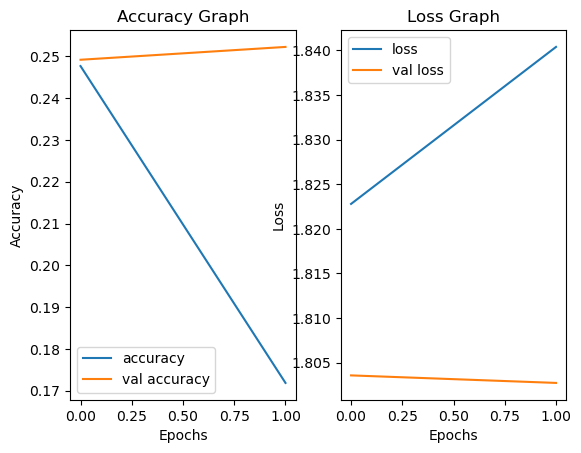

In [14]:
import matplotlib.pyplot as plt
 
# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(accuracy, label='accuracy')
plt.plot(val_accuracy, label='val accuracy')
plt.title('Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
 
# loss graph
plt.subplot(1, 2, 2)
plt.plot(loss, label='loss')
plt.plot(val_loss, label='val loss')
plt.title('Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
 
plt.show()


In [15]:

from tensorflow.keras.models import load_model
emotion_model.save("emotion_recognition_model_face.keras")


In [16]:

emotion_dict = {0: "Angry", 1: "Disgusted", 2: "Fearful", 
                3: "Happy", 4: "Neutral", 5: "Sad", 6: "Surprised"}



113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 143ms/step
Confusion Matrix:
[[   0    0    0  756    0  202    0]
 [   0    0    0   92    0   19    0]
 [   0    0    0  834    0  190    0]
 [   0    0    0 1445    0  329    0]
 [   0    0    0  998    0  235    0]
 [   0    0    0 1012    1  234    0]
 [   0    0    0  685    0  146    0]]

Classification Report:
              precision    recall  f1-score   support

       Angry       0.00      0.00      0.00       958
   Disgusted       0.00      0.00      0.00       111
     Fearful       0.00      0.00      0.00      1024
       Happy       0.25      0.81      0.38      1774
     Neutral       0.00      0.00      0.00      1233
         Sad       0.17      0.19      0.18      1247
   Surprised       0.00      0.00      0.00       831

    accuracy                           0.23      7178
   macro avg       0.06      0.14      0.08      7178
weighted avg       0.09      0.23      0.13      7178



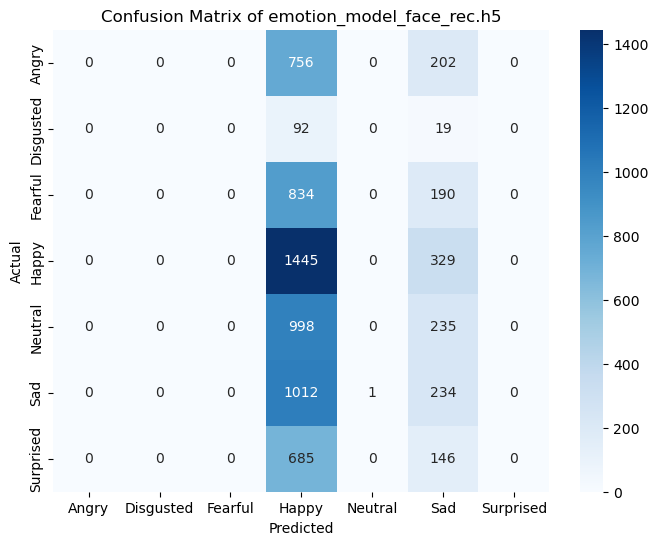

In [17]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
import seaborn as sns
y_pred_probabilities = emotion_model.predict(validation_generator)
y_pred = np.argmax(y_pred_probabilities, axis=1)  # Convert probabilities to class labels
test_labels  = ["Angry", "Disgusted",  "Fearful", 
                 "Happy", "Neutral",  "Sad",  "Surprised"]
true_labels = validation_generator.classes
# Create confusion matrix
conf_matrix = confusion_matrix(true_labels, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

# Print classification report
print("\nClassification Report:")
print(classification_report(true_labels, y_pred, target_names=test_labels))

# Plot confusion matrix using seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d', xticklabels=test_labels, yticklabels=test_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix of emotion_model_face_rec.h5')
plt.show()

In [18]:

# to identify the accuracy of each class 
FP = conf_matrix.sum(axis=0) - np.diag(conf_matrix)  
FN = conf_matrix.sum(axis=1) - np.diag(conf_matrix)
TP = np.diag(conf_matrix)
TN = conf_matrix.sum() - (FP + FN + TP)


# Overall accuracy
print ("Angry", "Disgusted",  "Fearful", 
                 "Happy", "Neutral",  "Sad",  "Surprised")
ACC = (TP+TN)/(TP+FP+FN+TN)
print (ACC)
Precision=(TP)/(TP+FP) 
print (Precision)
Recall= (TP)/(TP+FN)
print (Recall)
f1_score=(2 * Precision + Recall) / (Precision * Recall)
print (f1_score)


Angry Disgusted Fearful Happy Neutral Sad Surprised
[0.86653664 0.98453608 0.85734188 0.34438562 0.82808582 0.7027027
 0.88422959]
[       nan        nan        nan 0.2481965  0.         0.17269373
        nan]
[0.         0.         0.         0.8145434  0.         0.18765036
 0.        ]
[        nan         nan         nan  6.48442907         nan 16.44871795
         nan]


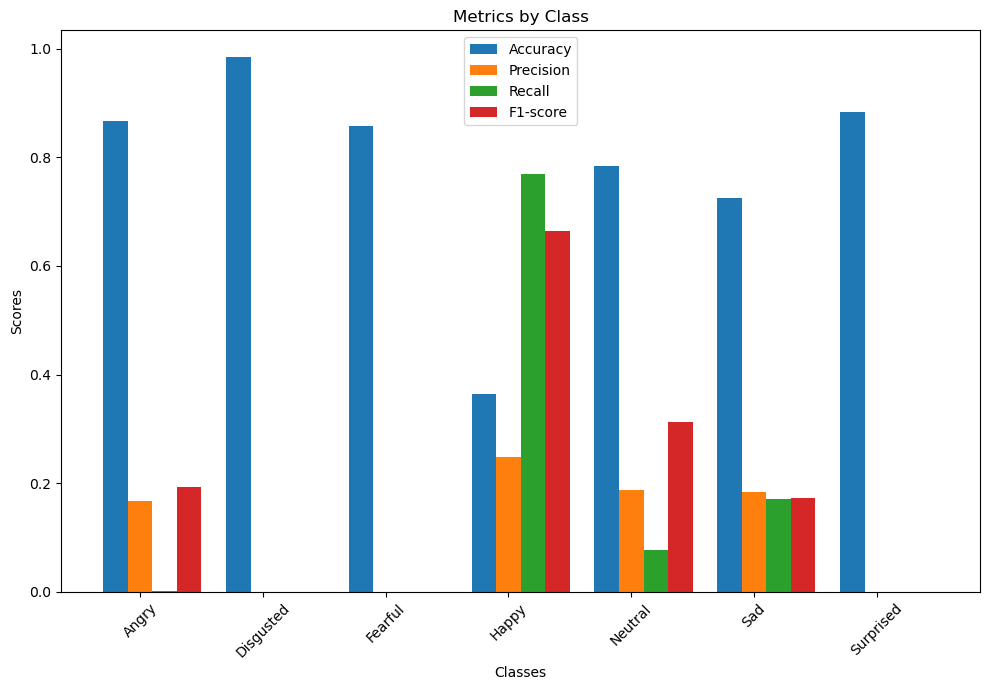

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming you have calculated the metrics for each class and stored them in lists or arrays

# List of classes (replace with your class names)
classes = ["Angry", "Disgusted",  "Fearful", 
                 "Happy", "Neutral",  "Sad",  "Surprised"]

# Example metrics for illustration (replace these with your actual metrics)
accuracy = np.array([0.86597938, 0.98453608, 0.85734188, 0.36472555, 0.78378378, 0.72527166, 0.88422959])
precision = np.array([0.16666667,        0,        0, 0.24737033, 0.18664047, 0.18450827, 0])
recall = np.array([0.00104384, 0. ,        0.  ,       0.76888388, 0.07704785, 0.17000802, 0.])
f1_score = np.array([0.1922, 0, 0, 0.664368501, 0.3131,0.1718396226,  0])

# Plotting the metrics for each class
x = np.arange(len(classes))
width = 0.2  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 7))

# Plotting accuracy
rects1 = ax.bar(x - width, accuracy, width, label='Accuracy')
# Plotting precision
rects2 = ax.bar(x, precision, width, label='Precision')
# Plotting recall
rects3 = ax.bar(x + width, recall, width, label='Recall')
# Plotting F1-score
rects4 = ax.bar(x + 2 * width, f1_score, width, label='F1-score')

# Adding labels, title, and legend
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Metrics by Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

# Show plot
plt.xticks(rotation=45)  # Rotate x-labels for better readability
plt.tight_layout()
plt.show()


113/113 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step 


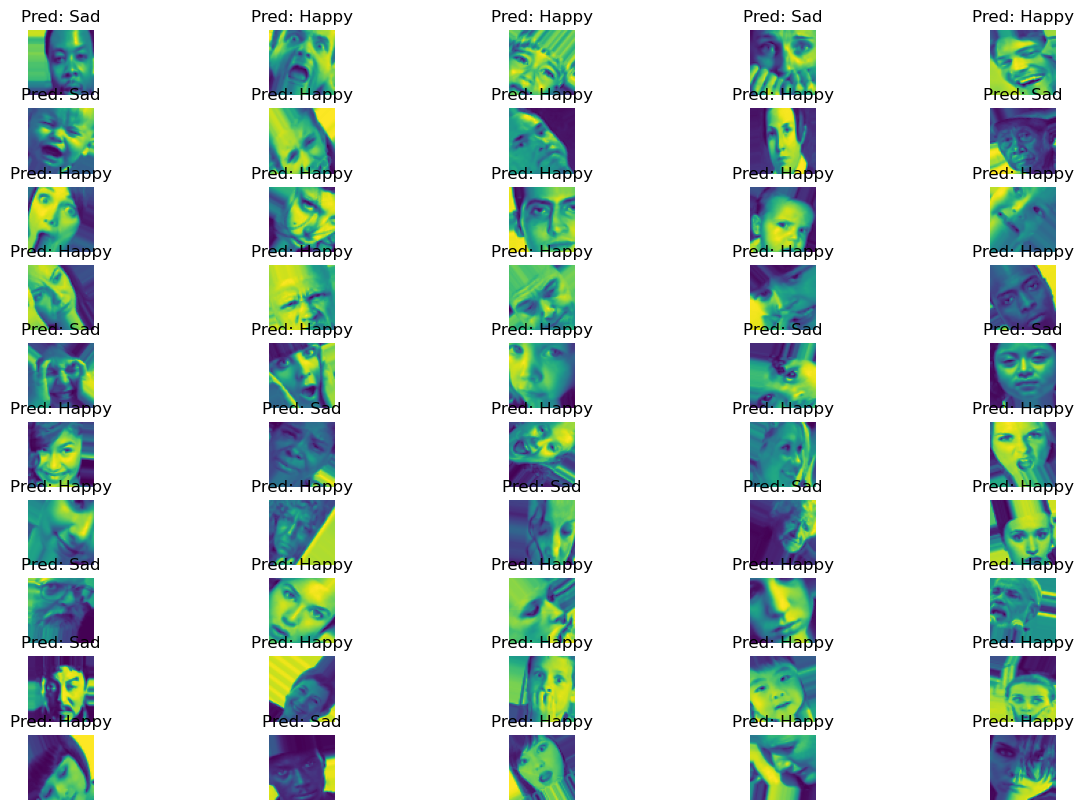

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model

# Load your trained model
emotion_model = load_model('emotion_recognition_model_face.keras')  # Replace 'your_model_path_here' with the actual path

# Assuming you have the validation generator ('validation_generator')
# Make predictions on the validation data
preds = emotion_model.predict(validation_generator)

# Mapping class indices to their respective labels
class_labels = ["Angry", "Disgusted", "Fearful", "Happy", "Neutral", "Sad", "Surprised"]

# Display images with predicted and true labels
for i in range(10):
    # Get a batch of validation data (images and labels)
    validation_data_batch = validation_generator[i]
    images = validation_data_batch[0]  # Images
    true_labels_batch = validation_data_batch[1]  # True labels

    # Predict on the batch of images
    pred_labels_batch = emotion_model.predict(images)
    plt.figure(figsize=(15, 10))
    # Display each image with its predicted and true labels
    for j in range(len(images)):
        subplot_index = i * len(images) + j + 1
        if subplot_index <= 50:  # Ensure the subplot index doesn't exceed 50
            plt.subplot(10, 5, subplot_index)
            plt.title('Pred: {}'.format(class_labels[np.argmax(pred_labels_batch[j])], class_labels[np.argmax(true_labels_batch[j])]))
            #plt.title('Pred: {}'.format(class_labels[np.argmax(preds[i])], class_labels[np.argmax(test_y[i])]))
            plt.imshow(images[j])  # Display the image
            plt.axis('off')

plt.tight_layout()
plt.show()



In [21]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load the emotion detection model
emotion_model = load_model('emotion_recognition_model_face.keras')

# Check the model's expected input shape
model_input_shape = emotion_model.input_shape
print("Model expects input shape:", model_input_shape)

# Define emotion labels
emotion_labels = {0: 'Angry', 1: 'Disgust', 2: 'Fear', 3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'}

# Load Haarcascade for face detection
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Open webcam
cap = cv2.VideoCapture(0)

while True: 
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)

    for (x, y, w, h) in faces:
        detected_face = gray[y:y + h, x:x + w]

        # Resize to match model input
        if model_input_shape[1] == 48:
            resized_face = cv2.resize(detected_face, (48, 48))
        else:
            resized_face = cv2.resize(detected_face, (224, 224))

        # Normalize
        normalized_face = resized_face / 255.0
        processed_face = np.expand_dims(normalized_face, axis=0)  # Add batch dimension

        # Add channel dimension if required
        if model_input_shape[-1] == 1:
            processed_face = np.expand_dims(processed_face, axis=-1)  # Grayscale
        elif model_input_shape[-1] == 3:
            processed_face = np.repeat(processed_face, 3, axis=-1)  # Convert grayscale to RGB

        # Predict emotion
        emotion_probs = emotion_model.predict(processed_face)
        predicted_emotion_label = np.argmax(emotion_probs)
        predicted_emotion = emotion_labels.get(predicted_emotion_label, "Unknown")

        # Draw rectangle and label
        cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.putText(frame, f"Emotion: {predicted_emotion}", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36, 255, 12), 2)

    # Show frame
    cv2.imshow('Real-time Emotion Detection', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Model expects input shape: (None, 48, 48, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 784ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1